# BERT Fine-Tuning for Twitter Sentiment Analysis
**Dataset:** Twitter US Airline Sentiment  
**Model:** bert-base-uncased  
**Task:** 3-class sentiment classification (Negative / Neutral / Positive)  
**Experiments:** Frozen BERT vs Fine-tuned Last 2 Layers

In [ ]:
!pip install transformers torch scikit-learn -q
import pandas as pd
import torch
print(torch.cuda.is_available())

True


##**Import lobraries**

In [3]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


##**Load dataset**

In [4]:
df = pd.read_csv('Tweets.csv')
print(df.shape)
print(df['airline_sentiment'].value_counts())
df.head()

(14640, 15)
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


##**Preprocessing**

In [5]:
# filter the dataset
df = df[['text', 'airline_sentiment']].dropna()

# Encode labels
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df['label'] = df['airline_sentiment'].map(label_map)

import re
def clean_text(text):
    text = re.sub(r'http\S+', '', text)        # remove URLs
    text = re.sub(r'@\w+', '', text)           # remove mentions
    text = re.sub(r'[^a-zA-Z\s]', '', text)   # remove special chars
    text = text.lower().strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)
df = df[df['clean_text'].str.len() > 0]  # drop empty rows
print(df.shape)
df[['text', 'clean_text', 'label']].head()

(14640, 4)


,text,clean_text,label
0,@VirginAmerica What @dhepburn said.,what said,1
1,@VirginAmerica plus you've added commercials t...,plus youve added commercials to the experience...,2
2,@VirginAmerica I didn't today... Must mean I n...,i didnt today must mean i need to take another...,1
3,@VirginAmerica it's really aggressive to blast...,its really aggressive to blast obnoxious enter...,0
4,@VirginAmerica and it's a really big bad thing...,and its a really big bad thing about it,0


##**Split the data**

In [7]:
X = df['clean_text'].values
y = df['label'].values

# Train / Val / Test split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 11712 | Val: 1464 | Test: 1464


##**Tokenize**

In [8]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize(texts, max_length=128):
    return tokenizer(
        list(texts),
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

train_encodings = tokenize(X_train)
val_encodings = tokenize(X_val)
test_encodings = tokenize(X_test)
print("Tokenization done")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenization done


##**Dataset classes**



In [9]:
class SentimentDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

train_dataset = SentimentDataset(train_encodings, y_train)
val_dataset = SentimentDataset(val_encodings, y_val)
test_dataset = SentimentDataset(test_encodings, y_test)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)
print("Dataloaders ready")

Dataloaders ready


##**Shared evaluation function**

In [10]:
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted')
    cm = confusion_matrix(all_labels, all_preds)
    return acc, precision, recall, f1, cm

##**Experiment 1: Frozen BERT Layers**

In [11]:
# Load fresh model
model_exp1 = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=3)
model_exp1.to(device)

# Freeze ALL BERT layers - only classifier head will learn
for name, param in model_exp1.named_parameters():
    if 'classifier' not in name:
        param.requires_grad = False

# Verify what's trainable
trainable = sum(p.numel() for p in model_exp1.parameters() if p.requires_grad)
print(f"Experiment 1 - Trainable parameters: {trainable:,}")

optimizer_exp1 = AdamW(filter(lambda p: p.requires_grad, model_exp1.parameters()), lr=2e-5)

# Training loop - 3 epochs
EPOCHS = 3
for epoch in range(EPOCHS):
    model_exp1.train()
    total_loss = 0

    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer_exp1.zero_grad()
        outputs = model_exp1(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer_exp1.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    val_acc, _, _, val_f1, _ = evaluate(model_exp1, val_loader)
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

print("\nExperiment 1 Training Complete")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Experiment 1 - Trainable parameters: 2,307
Epoch 1/3 | Loss: 0.9424 | Val Acc: 0.6270 | Val F1: 0.4840
Epoch 2/3 | Loss: 0.9043 | Val Acc: 0.6270 | Val F1: 0.4840
Epoch 3/3 | Loss: 0.8915 | Val Acc: 0.6264 | Val F1: 0.4825

Experiment 1 Training Complete


##**Experiment 2: Fine-tuned Last 2 BERT Layers**

In [12]:
# Load fresh model
model_exp2 = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=3)
model_exp2.to(device)

# Freeze all layers first
for param in model_exp2.parameters():
    param.requires_grad = False

# Unfreeze last 2 encoder layers + classifier
for name, param in model_exp2.named_parameters():
    if 'encoder.layer.10' in name or 'encoder.layer.11' in name or 'classifier' in name:
        param.requires_grad = True

trainable = sum(p.numel() for p in model_exp2.parameters() if p.requires_grad)
print(f"Experiment 2 - Trainable parameters: {trainable:,}")

optimizer_exp2 = AdamW(filter(lambda p: p.requires_grad, model_exp2.parameters()), lr=2e-5)

# Training loop - 3 epochs
for epoch in range(EPOCHS):
    model_exp2.train()
    total_loss = 0

    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer_exp2.zero_grad()
        outputs = model_exp2(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer_exp2.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    val_acc, _, _, val_f1, _ = evaluate(model_exp2, val_loader)
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

print("\nExperiment 2 Training Complete")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Experiment 2 - Trainable parameters: 14,178,051
Epoch 1/3 | Loss: 0.6046 | Val Acc: 0.8026 | Val F1: 0.7896
Epoch 2/3 | Loss: 0.4555 | Val Acc: 0.8149 | Val F1: 0.8096
Epoch 3/3 | Loss: 0.4185 | Val Acc: 0.8163 | Val F1: 0.8103

Experiment 2 Training Complete


##**Final eveluation and confusion matrix**

EXPERIMENT 1 - Frozen BERT (Classifier Only)
Accuracy:  0.6270
Precision: 0.3932
Recall:    0.6270
F1 Score:  0.4833

EXPERIMENT 2 - Fine-tuned Last 2 BERT Layers
Accuracy:  0.8292
Precision: 0.8236
Recall:    0.8292
F1 Score:  0.8247


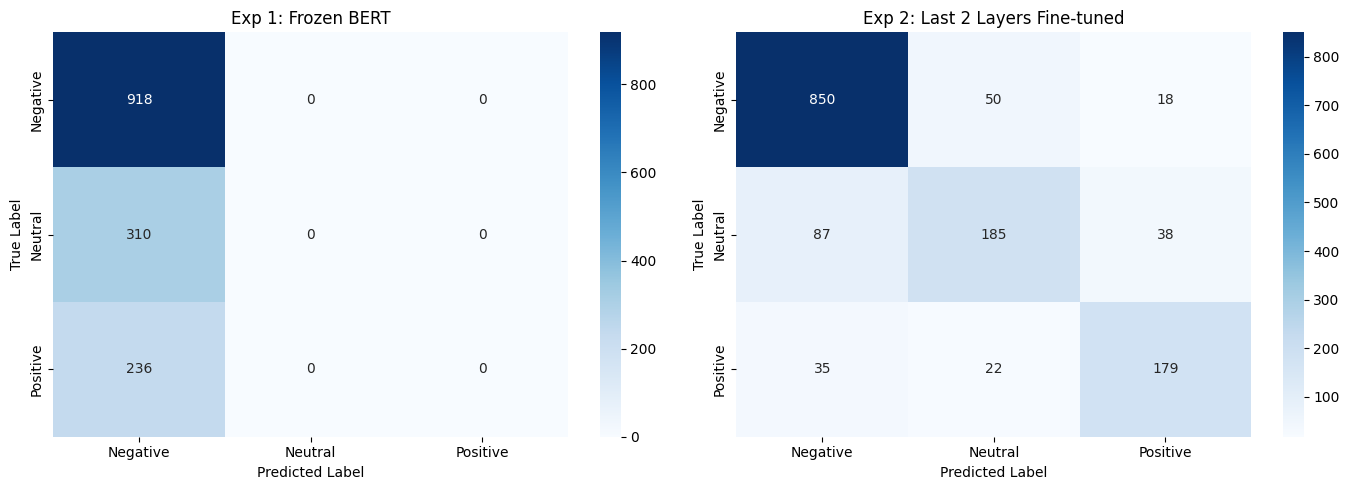

In [13]:
# Evaluate both models on test set
acc1, prec1, rec1, f1_1, cm1 = evaluate(model_exp1, test_loader)
acc2, prec2, rec2, f1_2, cm2 = evaluate(model_exp2, test_loader)

# Print metrics
print("=" * 50)
print("EXPERIMENT 1 - Frozen BERT (Classifier Only)")
print(f"Accuracy:  {acc1:.4f}")
print(f"Precision: {prec1:.4f}")
print(f"Recall:    {rec1:.4f}")
print(f"F1 Score:  {f1_1:.4f}")

print("\n" + "=" * 50)
print("EXPERIMENT 2 - Fine-tuned Last 2 BERT Layers")
print(f"Accuracy:  {acc2:.4f}")
print(f"Precision: {prec2:.4f}")
print(f"Recall:    {rec2:.4f}")
print(f"F1 Score:  {f1_2:.4f}")

# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = ['Negative', 'Neutral', 'Positive']

for ax, cm, title in zip(axes, [cm1, cm2],
                          ['Exp 1: Frozen BERT', 'Exp 2: Last 2 Layers Fine-tuned']):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(title)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## **Analysis & Comparison**

### Dataset
Twitter US Airline Sentiment — 14,640 tweets, 3 classes: Negative, Neutral, Positive.
Preprocessed by removing URLs, mentions, and special characters.
Split: 80% train, 10% validation, 10% test.

### Experiment 1: Frozen BERT Layers
Only the classifier head (2,307 parameters) was trained.
BERT's pretrained weights remained completely unchanged.
Result: The model failed to adapt to tweet-specific sentiment patterns.
Validation accuracy plateaued at 62.7% with F1 of 0.48 across all 3 epochs,
indicating the frozen general-purpose features were insufficient for this domain.

### Experiment 2: Fine-tuned Last 2 BERT Layers
Layers 10, 11 and the classifier head (14,178,051 parameters) were unfrozen.
The loss dropped consistently: 0.60 → 0.45 → 0.41.
Validation accuracy reached 81.6% with F1 of 0.81 — a 19% absolute improvement.

### Why the Difference?
BERT's last layers produce the highest-level semantic representations.
When frozen, these representations are generic (pretrained on Wikipedia/BookCorpus).
Fine-tuning them allows BERT to reshape its feature space toward sentiment-relevant
signals in noisy, short social media text — leading to significantly better classification.

### Conclusion
Fine-tuning even just the last 2 layers of BERT produces dramatically better results
than training only the classifier head. The quality of features passed to the classifier
directly determines model performance. Domain adaptation at the representation level
is critical for specialized NLP tasks.